<a href="https://colab.research.google.com/github/Anuj2606/Skip-Connection-U-Net-Segmentation-Quality/blob/main/Skip_Connections_in_U_Net_A_Segmentation_Ablation_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Skip Connections in U-Net: A Segmentation Ablation Study


## Objective

This project investigates the impact of the U-Net architecture
and skip connections on semantic segmentation performance.

Two architectures are compared:

1. Baseline Encoder-Decoder
2. U-Net with Skip Connections

A second experiment studies the effect of the loss function:

1. Cross-Entropy Loss
2. Dice + Cross-Entropy Loss

### Dataset
Oxford-IIIT Pet Dataset

### Evaluation Metrics
- Mean Intersection over Union (Mean IoU)
- Mean Dice Score

In [11]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from PIL import Image

In [13]:
# Set random seed
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [14]:
IMG_SIZE = 128
BATCH_SIZE = 16

NUM_CLASSES = 3

LEARNING_RATE = 0.001
MAX_EPOCHS = 30
PATIENCE = 5

print("Image Size:", IMG_SIZE)
print("Batch Size:", BATCH_SIZE)
print("Number of Classes:", NUM_CLASSES)

Image Size: 128
Batch Size: 16
Number of Classes: 3


In [15]:
image_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])


def mask_transform(mask):
    mask = mask.resize(
        (IMG_SIZE, IMG_SIZE),
        Image.Resampling.NEAREST
    )

    mask = np.array(mask, dtype=np.int64)

    # Oxford-IIIT Pet masks use labels 1, 2, 3
    # Convert them to 0, 1, 2 for CrossEntropyLoss
    mask = torch.tensor(mask - 1, dtype=torch.long)

    return mask

In [16]:
trainval_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    transform=image_transform,
    target_transform=mask_transform,
    download=True
)

test_dataset = datasets.OxfordIIITPet(
    root="./data",
    split="test",
    target_types="segmentation",
    transform=image_transform,
    target_transform=mask_transform,
    download=True
)

print("Train + Validation samples:", len(trainval_dataset))
print("Test samples:", len(test_dataset))

Train + Validation samples: 3680
Test samples: 3669


In [17]:
train_size = int(0.8 * len(trainval_dataset))
val_size = len(trainval_dataset) - train_size

train_dataset, val_dataset = random_split(
    trainval_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print("Training samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Test samples:", len(test_dataset))

Training samples: 2944
Validation samples: 736
Test samples: 3669


In [18]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

In [19]:
images, masks = next(iter(train_loader))

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

print("Mask values:", torch.unique(masks))

Images shape: torch.Size([16, 3, 128, 128])
Masks shape: torch.Size([16, 128, 128])
Mask values: tensor([0, 1, 2])


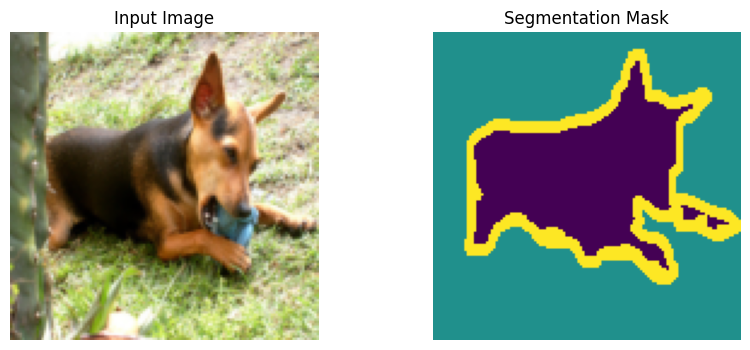

In [20]:
image = images[0]
mask = masks[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Input Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(mask)
plt.title("Segmentation Mask")
plt.axis("off")

plt.show()

In [21]:
class SimpleEncoderDecoder(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(
                128, 64,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.ConvTranspose2d(
                64, 32,
                kernel_size=2,
                stride=2
            ),
            nn.ReLU(),

            nn.Conv2d(
                32,
                NUM_CLASSES,
                kernel_size=1
            )
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)

        return x

In [22]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        # Encoder 1
        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        self.pool1 = nn.MaxPool2d(2)

        # Encoder 2
        self.enc2 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        self.pool2 = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = nn.Sequential(
            nn.Conv2d(128, 256, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, 3, padding=1),
            nn.ReLU()
        )

        # Decoder 2
        self.up2 = nn.ConvTranspose2d(
            256, 128,
            kernel_size=2,
            stride=2
        )

        self.dec2 = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.ReLU()
        )

        # Decoder 1
        self.up1 = nn.ConvTranspose2d(
            128, 64,
            kernel_size=2,
            stride=2
        )

        self.dec1 = nn.Sequential(
            nn.Conv2d(128, 64, 3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU()
        )

        # Final layer
        self.output = nn.Conv2d(
            64,
            NUM_CLASSES,
            kernel_size=1
        )

    def forward(self, x):

        # Encoder
        e1 = self.enc1(x)
        p1 = self.pool1(e1)

        e2 = self.enc2(p1)
        p2 = self.pool2(e2)

        # Bottleneck
        b = self.bottleneck(p2)

        # Decoder + Skip Connection
        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        # Decoder + Skip Connection
        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        # Output
        return self.output(d1)

In [23]:
baseline_model = SimpleEncoderDecoder().to(device)
unet_model = UNet().to(device)

print(baseline_model)
print(unet_model)

SimpleEncoderDecoder(
  (encoder): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(128, 64, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(64, 32, kernel_size=(2, 2), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 3, kernel_size=(1, 1), stride=(1, 1))
  )
)
UNet(
  (enc1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
  )
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): Sequential(
    (0): Conv2d(64, 

In [24]:
sample_images, _ = next(iter(train_loader))

sample_images = sample_images.to(device)

with torch.no_grad():

    baseline_output = baseline_model(sample_images)
    unet_output = unet_model(sample_images)

print("Input:", sample_images.shape)
print("Baseline output:", baseline_output.shape)
print("U-Net output:", unet_output.shape)

Input: torch.Size([16, 3, 128, 128])
Baseline output: torch.Size([16, 3, 128, 128])
U-Net output: torch.Size([16, 3, 128, 128])


In [25]:
criterion = nn.CrossEntropyLoss()

In [26]:
def train_model(model, train_loader, val_loader, epochs=MAX_EPOCHS):

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):

        # -------------------------
        # Training
        # -------------------------

        model.train()

        running_train_loss = 0.0

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = criterion(
                outputs,
                masks
            )

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item()

        train_loss = (
            running_train_loss / len(train_loader)
        )

        # -------------------------
        # Validation
        # -------------------------

        model.eval()

        running_val_loss = 0.0

        with torch.no_grad():

            for images, masks in val_loader:

                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)

                loss = criterion(
                    outputs,
                    masks
                )

                running_val_loss += loss.item()

        val_loss = (
            running_val_loss / len(val_loader)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )

        # -------------------------
        # Early Stopping
        # -------------------------

        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping.")
            break

    return train_losses, val_losses

In [27]:
print("Training Baseline Encoder-Decoder")

baseline_train_losses, baseline_val_losses = train_model(
    baseline_model,
    train_loader,
    val_loader
)

Training Baseline Encoder-Decoder
Epoch [1/30] Train Loss: 0.9169 Val Loss: 0.8652
Epoch [2/30] Train Loss: 0.8058 Val Loss: 0.7676
Epoch [3/30] Train Loss: 0.7626 Val Loss: 0.7489
Epoch [4/30] Train Loss: 0.7384 Val Loss: 0.7576
Epoch [5/30] Train Loss: 0.7293 Val Loss: 0.7145
Epoch [6/30] Train Loss: 0.7166 Val Loss: 0.7334
Epoch [7/30] Train Loss: 0.7154 Val Loss: 0.7038
Epoch [8/30] Train Loss: 0.7008 Val Loss: 0.6963
Epoch [9/30] Train Loss: 0.6957 Val Loss: 0.7369
Epoch [10/30] Train Loss: 0.6996 Val Loss: 0.6933
Epoch [11/30] Train Loss: 0.6896 Val Loss: 0.6838
Epoch [12/30] Train Loss: 0.6879 Val Loss: 0.6792
Epoch [13/30] Train Loss: 0.6854 Val Loss: 0.6868
Epoch [14/30] Train Loss: 0.6798 Val Loss: 0.6806
Epoch [15/30] Train Loss: 0.6732 Val Loss: 0.6765
Epoch [16/30] Train Loss: 0.6712 Val Loss: 0.6774
Epoch [17/30] Train Loss: 0.6694 Val Loss: 0.6764
Epoch [18/30] Train Loss: 0.6654 Val Loss: 0.6821
Epoch [19/30] Train Loss: 0.6621 Val Loss: 0.6565
Epoch [20/30] Train Loss:

In [28]:
print("Training U-Net")

unet_train_losses, unet_val_losses = train_model(
    unet_model,
    train_loader,
    val_loader
)

Training U-Net
Epoch [1/30] Train Loss: 0.8429 Val Loss: 0.7554
Epoch [2/30] Train Loss: 0.7202 Val Loss: 0.7012
Epoch [3/30] Train Loss: 0.6878 Val Loss: 0.6622
Epoch [4/30] Train Loss: 0.6601 Val Loss: 0.6112
Epoch [5/30] Train Loss: 0.6441 Val Loss: 0.5959
Epoch [6/30] Train Loss: 0.5741 Val Loss: 0.5368
Epoch [7/30] Train Loss: 0.5491 Val Loss: 0.5211
Epoch [8/30] Train Loss: 0.5038 Val Loss: 0.5506
Epoch [9/30] Train Loss: 0.4868 Val Loss: 0.4687
Epoch [10/30] Train Loss: 0.4637 Val Loss: 0.4708
Epoch [11/30] Train Loss: 0.4580 Val Loss: 0.4333
Epoch [12/30] Train Loss: 0.4516 Val Loss: 0.4431
Epoch [13/30] Train Loss: 0.4328 Val Loss: 0.4481
Epoch [14/30] Train Loss: 0.4199 Val Loss: 0.4159
Epoch [15/30] Train Loss: 0.4101 Val Loss: 0.4085
Epoch [16/30] Train Loss: 0.4018 Val Loss: 0.4229
Epoch [17/30] Train Loss: 0.4026 Val Loss: 0.4074
Epoch [18/30] Train Loss: 0.3889 Val Loss: 0.3968
Epoch [19/30] Train Loss: 0.3775 Val Loss: 0.4208
Epoch [20/30] Train Loss: 0.3753 Val Loss: 0

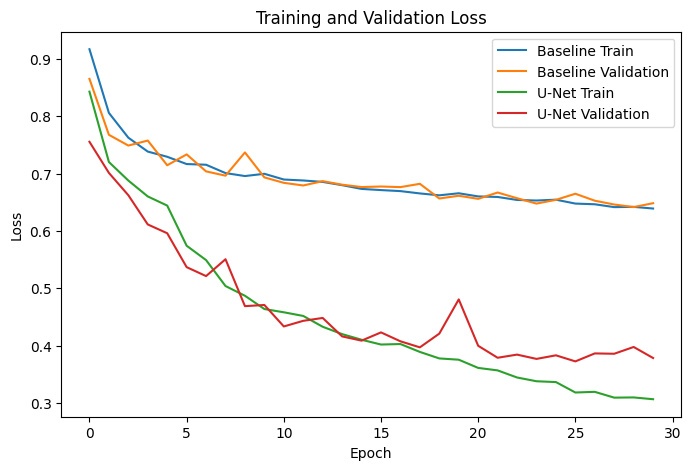

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(
    baseline_train_losses,
    label="Baseline Train"
)

plt.plot(
    baseline_val_losses,
    label="Baseline Validation"
)

plt.plot(
    unet_train_losses,
    label="U-Net Train"
)

plt.plot(
    unet_val_losses,
    label="U-Net Validation"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

The U-Net training loss decreased substantially during training and reached a lower final loss than the baseline. Its validation loss was also lower than the baseline for most epochs, indicating better validation performance during training.

In [30]:
def calculate_metrics(model, data_loader):

    model.eval()

    total_iou = 0.0
    total_dice = 0.0

    count = 0

    with torch.no_grad():

        for images, masks in data_loader:

            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)

            predictions = torch.argmax(
                outputs,
                dim=1
            )

            for class_id in range(NUM_CLASSES):

                pred_class = predictions == class_id
                true_class = masks == class_id

                intersection = (
                    pred_class & true_class
                ).sum().item()

                union = (
                    pred_class | true_class
                ).sum().item()

                pred_pixels = pred_class.sum().item()
                true_pixels = true_class.sum().item()

                # IoU
                if union > 0:
                    iou = intersection / union
                else:
                    iou = 1.0

                # Dice
                denominator = (
                    pred_pixels + true_pixels
                )

                if denominator > 0:
                    dice = (
                        2 * intersection / denominator
                    )
                else:
                    dice = 1.0

                total_iou += iou
                total_dice += dice
                count += 1

    mean_iou = total_iou / count
    mean_dice = total_dice / count

    return mean_iou, mean_dice

In [31]:
baseline_iou, baseline_dice = calculate_metrics(
    baseline_model,
    test_loader
)

print("Baseline Encoder-Decoder")
print("-------------------------")
print(f"Mean IoU: {baseline_iou:.4f}")
print(f"Dice Score: {baseline_dice:.4f}")

Baseline Encoder-Decoder
-------------------------
Mean IoU: 0.4487
Dice Score: 0.5902


In [32]:
unet_iou, unet_dice = calculate_metrics(
    unet_model,
    test_loader
)

print("U-Net")
print("-------------------------")
print(f"Mean IoU: {unet_iou:.4f}")
print(f"Dice Score: {unet_dice:.4f}")

U-Net
-------------------------
Mean IoU: 0.6538
Dice Score: 0.7756


In [33]:
print("Architecture Comparison")
print("========================")

print(
    f"Baseline Mean IoU : {baseline_iou:.4f}"
)

print(
    f"U-Net Mean IoU    : {unet_iou:.4f}"
)

print()

print(
    f"Baseline Dice     : {baseline_dice:.4f}"
)

print(
    f"U-Net Dice        : {unet_dice:.4f}"
)

Architecture Comparison
Baseline Mean IoU : 0.4487
U-Net Mean IoU    : 0.6538

Baseline Dice     : 0.5902
U-Net Dice        : 0.7756


U-Net achieved higher segmentation performance than the baseline encoder-decoder. Mean IoU increased from 0.4487 to 0.6538, while Dice Score increased from 0.5902 to 0.7756. This indicates that the U-Net with skip connections produced better overlap between predicted and ground-truth segmentation masks.

In [34]:
class DiceCELoss(nn.Module):

    def __init__(self):
        super().__init__()

        self.cross_entropy = nn.CrossEntropyLoss()

    def forward(self, outputs, targets):

        # Cross-Entropy Loss
        ce_loss = self.cross_entropy(
            outputs,
            targets
        )

        # Convert output to probabilities
        probabilities = torch.softmax(
            outputs,
            dim=1
        )

        # One-hot encode target
        targets_one_hot = torch.nn.functional.one_hot(
            targets,
            num_classes=NUM_CLASSES
        )

        targets_one_hot = targets_one_hot.permute(
            0, 3, 1, 2
        ).float()

        # Calculate Dice
        intersection = (
            probabilities * targets_one_hot
        ).sum(dim=(2, 3))

        denominator = (
            probabilities.sum(dim=(2, 3))
            + targets_one_hot.sum(dim=(2, 3))
        )

        dice = (
            (2 * intersection + 1e-6)
            / (denominator + 1e-6)
        )

        dice_loss = 1 - dice.mean()

        return ce_loss + dice_loss

In [36]:
def train_unet_dice_ce(
    model,
    train_loader,
    val_loader,
    epochs=MAX_EPOCHS
):

    optimizer = optim.Adam(
        model.parameters(),
        lr=LEARNING_RATE
    )

    loss_function = DiceCELoss()

    train_losses = []
    val_losses = []

    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(epochs):

        # Training
        model.train()

        total_train_loss = 0.0

        for images, masks in train_loader:

            images = images.to(device)
            masks = masks.to(device)

            optimizer.zero_grad()

            outputs = model(images)

            loss = loss_function(
                outputs,
                masks
            )

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        train_loss = (
            total_train_loss / len(train_loader)
        )

        # Validation
        model.eval()

        total_val_loss = 0.0

        with torch.no_grad():

            for images, masks in val_loader:

                images = images.to(device)
                masks = masks.to(device)

                outputs = model(images)

                loss = loss_function(
                    outputs,
                    masks
                )

                total_val_loss += loss.item()

        val_loss = (
            total_val_loss / len(val_loader)
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Train Loss: {train_loss:.4f} "
            f"Val Loss: {val_loss:.4f}"
        )

        # Early stopping
        if val_loss < best_val_loss:

            best_val_loss = val_loss
            patience_counter = 0

        else:

            patience_counter += 1

        if patience_counter >= PATIENCE:

            print("Early stopping.")
            break

    return train_losses, val_losses

In [37]:
unet_dice_ce_model = UNet().to(device)

print("New U-Net created.")

New U-Net created.


In [38]:
print("Training U-Net with Dice + Cross-Entropy Loss")

dice_ce_train_losses, dice_ce_val_losses = train_unet_dice_ce(
    unet_dice_ce_model,
    train_loader,
    val_loader
)

Training U-Net with Dice + Cross-Entropy Loss
Epoch [1/30] Train Loss: 1.5536 Val Loss: 1.3405
Epoch [2/30] Train Loss: 1.2645 Val Loss: 1.2161
Epoch [3/30] Train Loss: 1.1556 Val Loss: 1.0762
Epoch [4/30] Train Loss: 1.0828 Val Loss: 1.1477
Epoch [5/30] Train Loss: 1.0012 Val Loss: 0.9508
Epoch [6/30] Train Loss: 0.9399 Val Loss: 0.8809
Epoch [7/30] Train Loss: 0.9001 Val Loss: 0.8980
Epoch [8/30] Train Loss: 0.8594 Val Loss: 0.8569
Epoch [9/30] Train Loss: 0.8431 Val Loss: 0.8259
Epoch [10/30] Train Loss: 0.8232 Val Loss: 0.7917
Epoch [11/30] Train Loss: 0.7793 Val Loss: 0.8428
Epoch [12/30] Train Loss: 0.7636 Val Loss: 0.7463
Epoch [13/30] Train Loss: 0.7344 Val Loss: 0.7694
Epoch [14/30] Train Loss: 0.7309 Val Loss: 0.7395
Epoch [15/30] Train Loss: 0.7173 Val Loss: 0.7641
Epoch [16/30] Train Loss: 0.7015 Val Loss: 0.7115
Epoch [17/30] Train Loss: 0.6930 Val Loss: 0.7103
Epoch [18/30] Train Loss: 0.6787 Val Loss: 0.7171
Epoch [19/30] Train Loss: 0.6619 Val Loss: 0.7024
Epoch [20/30]

In [39]:
dice_ce_iou, dice_ce_dice = calculate_metrics(
    unet_dice_ce_model,
    test_loader
)

print("U-Net + Dice + CE")
print("-------------------------")
print(f"Mean IoU: {dice_ce_iou:.4f}")
print(f"Dice Score: {dice_ce_dice:.4f}")

U-Net + Dice + CE
-------------------------
Mean IoU: 0.6564
Dice Score: 0.7787


In [40]:
print("FINAL RESULTS")
print("=" * 50)

print(
    f"Baseline Encoder-Decoder"
)
print(
    f"Mean IoU : {baseline_iou:.4f}"
)
print(
    f"Dice     : {baseline_dice:.4f}"
)

print()

print(
    f"U-Net + Cross-Entropy"
)
print(
    f"Mean IoU : {unet_iou:.4f}"
)
print(
    f"Dice     : {unet_dice:.4f}"
)

print()

print(
    f"U-Net + Dice + Cross-Entropy"
)
print(
    f"Mean IoU : {dice_ce_iou:.4f}"
)
print(
    f"Dice     : {dice_ce_dice:.4f}"
)

FINAL RESULTS
Baseline Encoder-Decoder
Mean IoU : 0.4487
Dice     : 0.5902

U-Net + Cross-Entropy
Mean IoU : 0.6538
Dice     : 0.7756

U-Net + Dice + Cross-Entropy
Mean IoU : 0.6564
Dice     : 0.7787


U-Net with Dice + Cross-Entropy achieved a Mean IoU of 0.6564 and Dice Score of 0.7787, slightly higher than U-Net with Cross-Entropy alone (0.6538 Mean IoU and 0.7756 Dice Score). The combined loss improved Mean IoU by 0.0026 and Dice Score by 0.0031.

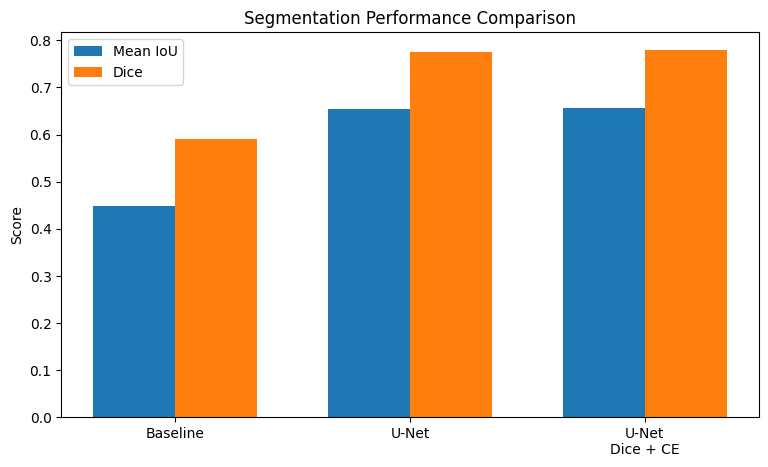

In [41]:
models = [
    "Baseline",
    "U-Net",
    "U-Net\nDice + CE"
]

iou_scores = [
    baseline_iou,
    unet_iou,
    dice_ce_iou
]

dice_scores = [
    baseline_dice,
    unet_dice,
    dice_ce_dice
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width / 2,
    iou_scores,
    width,
    label="Mean IoU"
)

plt.bar(
    x + width / 2,
    dice_scores,
    width,
    label="Dice"
)

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Segmentation Performance Comparison")
plt.legend()

plt.show()

In [42]:
def show_predictions(model, dataset, num_images=4):

    model.eval()

    plt.figure(figsize=(12, num_images * 3))

    for i in range(num_images):

        image, mask = dataset[i]

        input_image = image.unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(input_image)

            prediction = torch.argmax(
                output,
                dim=1
            )[0].cpu()

        # Input
        plt.subplot(num_images, 3, i * 3 + 1)

        plt.imshow(
            image.permute(1, 2, 0)
        )

        plt.title("Input")
        plt.axis("off")

        # Ground Truth
        plt.subplot(num_images, 3, i * 3 + 2)

        plt.imshow(mask)

        plt.title("Ground Truth")
        plt.axis("off")

        # Prediction
        plt.subplot(num_images, 3, i * 3 + 3)

        plt.imshow(prediction)

        plt.title("Prediction")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

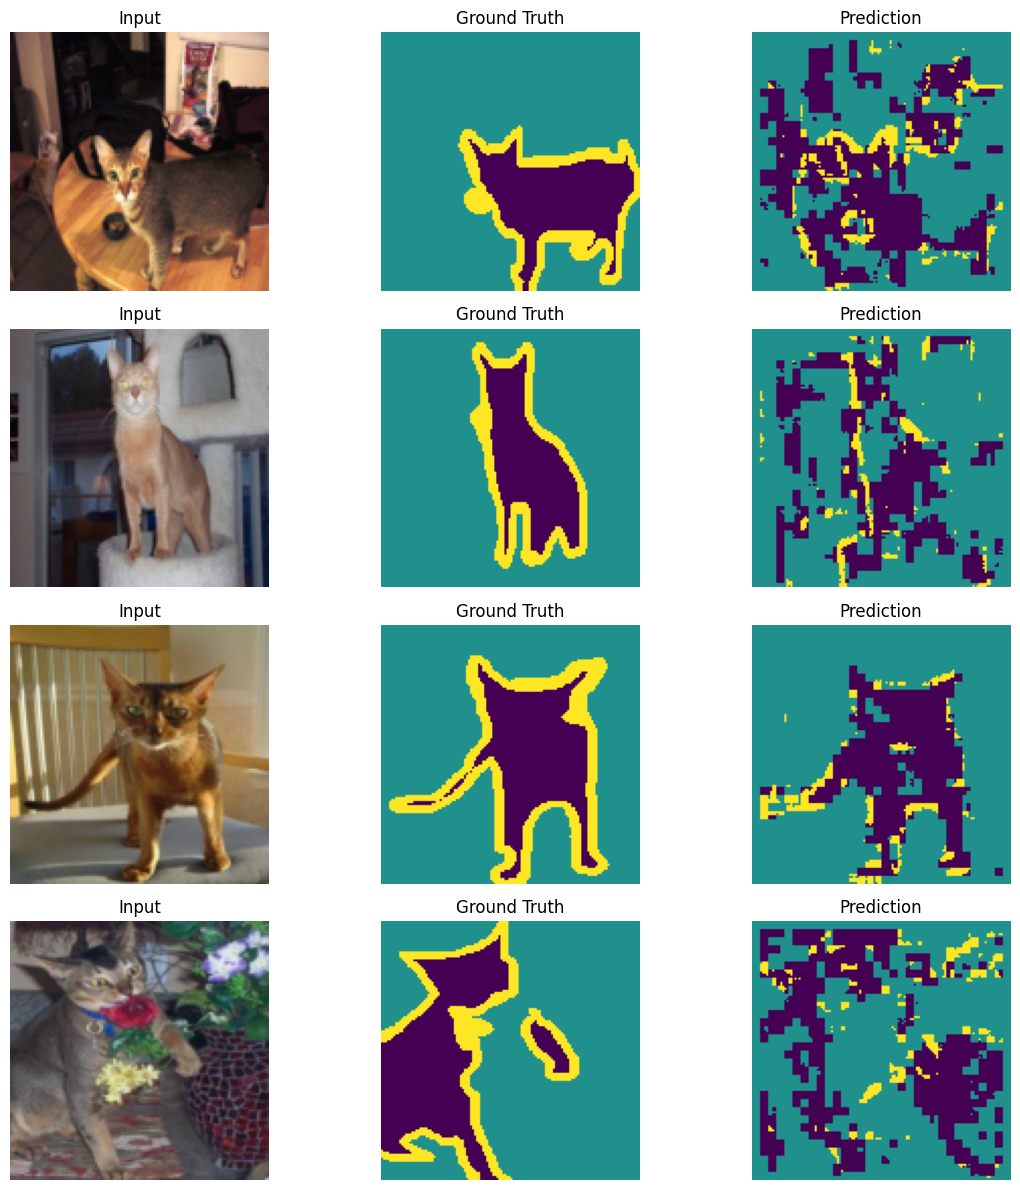

In [43]:
show_predictions(
    baseline_model,
    test_dataset,
    num_images=4
)

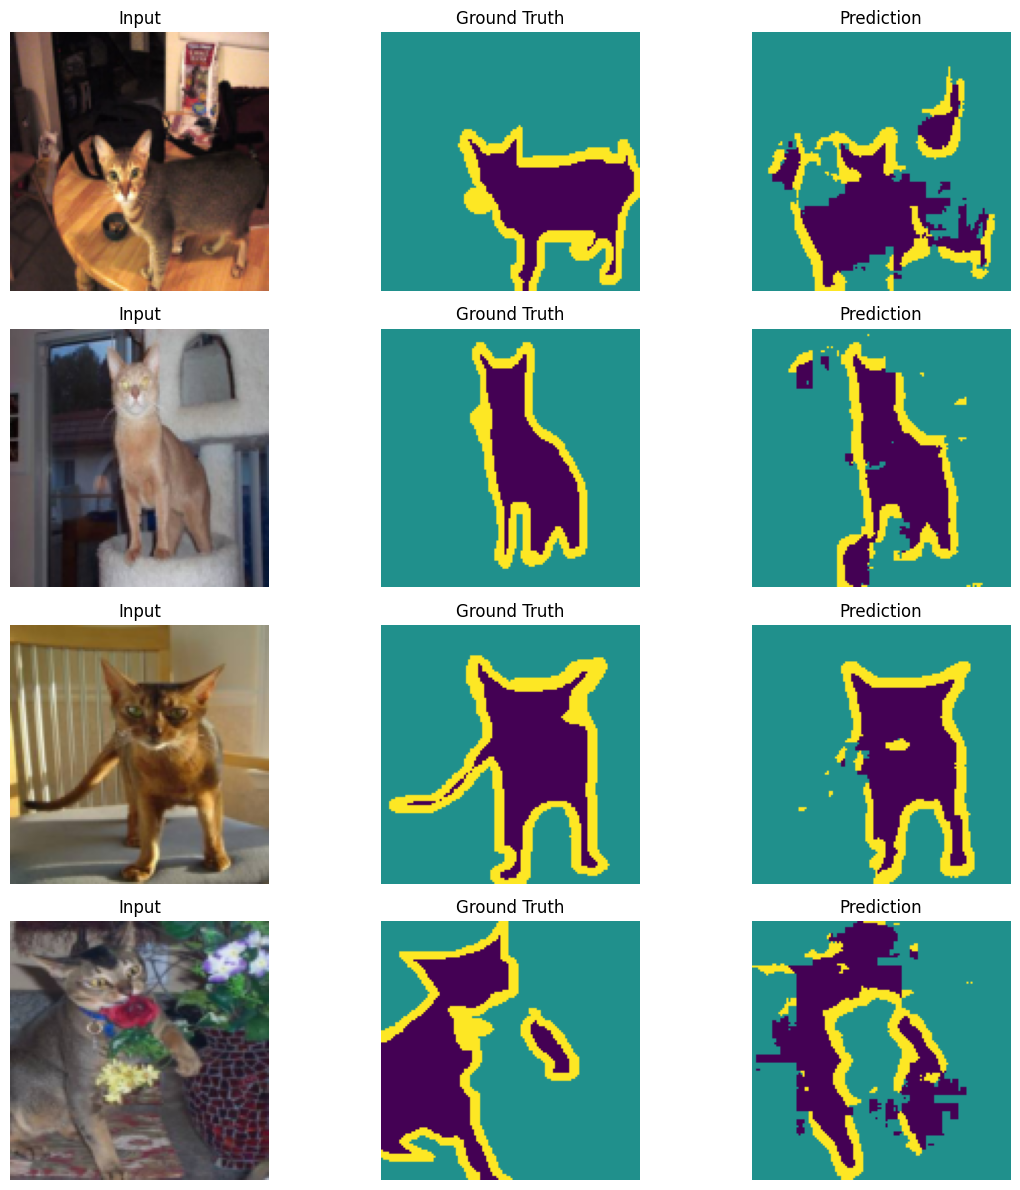

In [44]:
show_predictions(
    unet_model,
    test_dataset,
    num_images=4
)

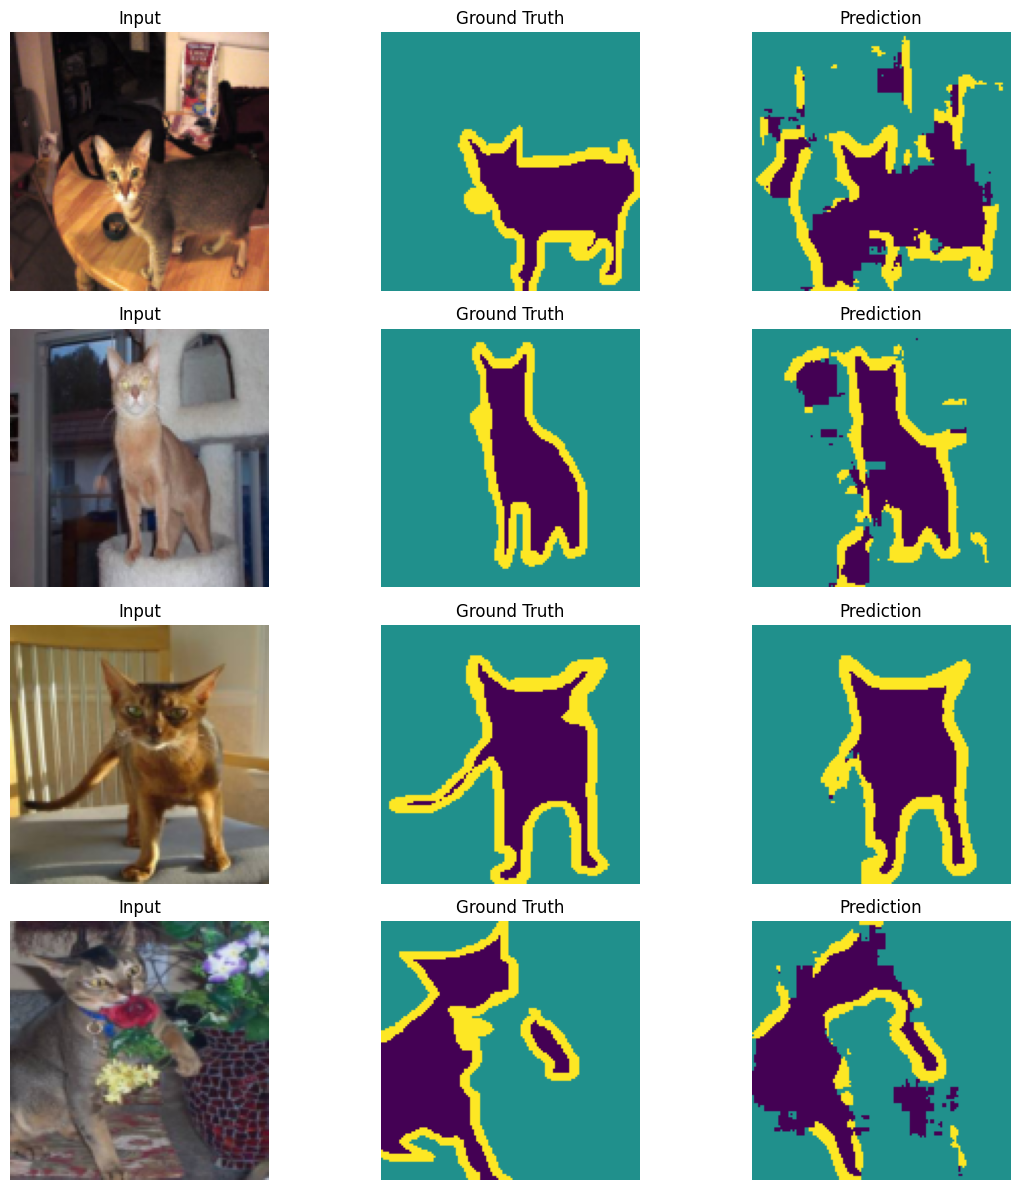

In [51]:
show_predictions(
    unet_dice_ce_model,
    test_dataset,
    num_images=4
)

In [49]:
architecture_iou_improvement = (
    (unet_iou - baseline_iou)
    / baseline_iou
) * 100

architecture_dice_improvement = (
    (unet_dice - baseline_dice)
    / baseline_dice
) * 100

loss_iou_improvement = (
    (dice_ce_iou - unet_iou)
    / unet_iou
) * 100

loss_dice_improvement = (
    (dice_ce_dice - unet_dice)
    / unet_dice
) * 100

print("Architecture Improvement")
print("-------------------------")
print(
    f"Mean IoU improvement: "
    f"{architecture_iou_improvement:.2f}%"
)

print(
    f"Dice improvement: "
    f"{architecture_dice_improvement:.2f}%"
)

print()

print("Loss Function Improvement")
print("-------------------------")
print(
    f"Mean IoU improvement: "
    f"{loss_iou_improvement:.2f}%"
)

print(
    f"Dice improvement: "
    f"{loss_dice_improvement:.2f}%"
)

Architecture Improvement
-------------------------
Mean IoU improvement: 45.73%
Dice improvement: 31.43%

Loss Function Improvement
-------------------------
Mean IoU improvement: 0.40%
Dice improvement: 0.40%


In [55]:
print("""

PROJECT CONCLUSION

==================

1. U-Net with skip connections achieved substantially better segmentation
   performance than the baseline Encoder-Decoder.

2. Mean IoU improved by 45.73% and Dice Score improved by 31.43%
   compared with the baseline.

3. Adding Dice Loss to Cross-Entropy resulted in a further 0.40%
   improvement in both Mean IoU and Dice Score.

4. 4. The results show that the U-Net architecture achieved substantially
   better segmentation performance than the baseline architecture.

5. The combined Dice + Cross-Entropy loss provided a small
   additional improvement over Cross-Entropy Loss alone.

""")



PROJECT CONCLUSION


1. U-Net with skip connections achieved substantially better segmentation
   performance than the baseline Encoder-Decoder.

2. Mean IoU improved by 45.73% and Dice Score improved by 31.43%
   compared with the baseline.

3. Adding Dice Loss to Cross-Entropy resulted in a further 0.40%
   improvement in both Mean IoU and Dice Score.

4. 4. The results show that the U-Net architecture achieved substantially
   better segmentation performance than the baseline architecture.

5. The combined Dice + Cross-Entropy loss provided a small
   additional improvement over Cross-Entropy Loss alone.


